In [1]:
import random
import json
import matplotlib.pyplot as plt

### Створити програму для генерації довільного масиву із 60 цілих чисел, які не перевищують по модулю 99, з наступними властивостями: 
####  1.1. При кожному запуску програми масив повинен бути різним.
#### 1.2. Масив повинен містити 30 відсотків від’ємних елементів (розташованих в довільних місцях)

In [2]:
def generte_arr():
    arr = [random.randint(-99, 99) for _ in range(60)] 
    neg_nums = int(0.3 * len(arr))
    indices = random.sample(range(len(arr)),neg_nums)
    for i in indices:
        arr[i] = -arr[i] # add minus to the number
    return arr



In [3]:
arr = generte_arr()

### 2. Зберегти згенерований масив в файл.
### 3. Створити програму, яка зчитує із файлу згенерований масив попередньою програмою і виводить його на екран

In [4]:
with open("output.txt","w") as filehandle:
    json.dump(arr,filehandle)

In [5]:
with open("output.txt",'r') as filehandle:
    data = json.load(filehandle)

In [6]:
print(data)

[-80, 92, 40, 4, 46, -99, 13, 20, -95, 62, -66, -96, -13, 74, -31, -92, -99, 53, 44, -8, -11, -67, 2, -63, -44, -17, 45, 40, 58, 57, -67, 69, 51, -62, -70, 35, 55, 61, -17, -72, 51, 21, -86, -95, 49, 46, -30, -71, -18, -20, -27, -96, -10, 70, 19, -26, -50, 16, -79, -72]


### 5. Порахувати номер позиції, та значення другого максимального елемента.


In [7]:
max1 = max(arr)
arr_without_max1 = [x for x in arr if x != max1]
max2 = max(arr)

print(f"Максимальне значення: {max2}") #that's for task5 in my variant

Максимальне значення: 92


### 6. Порахувати суму елементів масиву, розташованих до 10 додатного елемента.


In [8]:
pos_count = 0
sum_elements = 0
for num in arr:
    if num > 0:
        pos_count += 1
    if pos_count <= 10:    
        sum_elements += num
print(sum_elements)

-309


### Індекси максимальних значень


In [9]:
max1_index = arr.index(max1)
max2_index = arr.index(max2)

### Отримання інтервалу [a, b] від користувача


In [10]:
a = int(input("Введіть значення для a: "))
b = int(input("Введіть значення для b: "))

In [11]:
colors = []
for i, val in enumerate(arr):
    if i == max1_index:
        colors.append("red")  # Перший максимум - червоний
    elif i == max2_index:
        colors.append("orange")  # Другий максимум - помаранчевий
    elif a <= val <= b:
        colors.append("blue")  # Елементи в інтервалі [a, b] - сині
    else:
        colors.append("gray")  # Інші - сірі


### 4. Візуалізувати масив за допомогою стовпчастої вертикальної діаграми. Виділити кольором максимальний та другий максимальний елементи, а також вказати ці значення на діаграмі. Виділити іншим кольором елементи із інтервалу [a,b], який задає користувач

Text(0, 0.5, 'Значення')

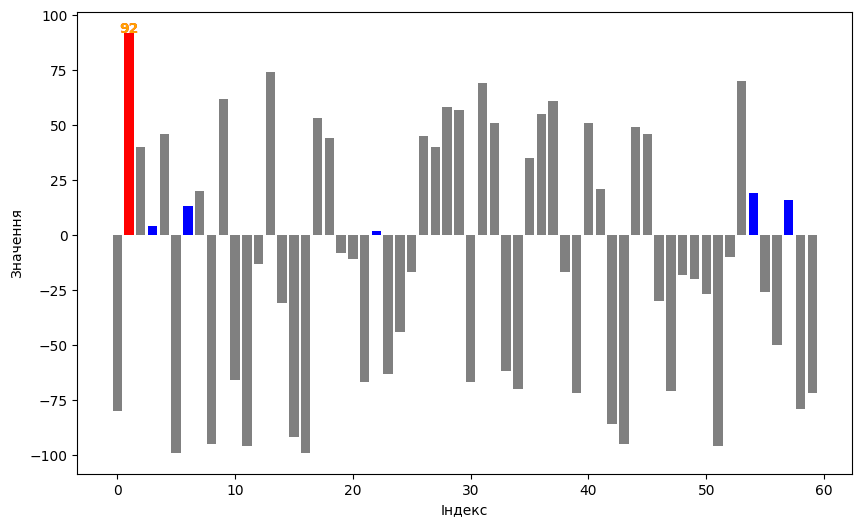

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(arr)), arr, color=colors)
plt.text(max1_index, max1, f'{max1}', ha='center', color="red", fontweight="bold")
plt.text(max2_index, max2, f'{max2}', ha='center', color="orange", fontweight="bold")

plt.xlabel("Індекс")
plt.ylabel("Значення")


### 7. Перетворити масив таким чином, щоб спочатку йшли всі елементи із інтервалу [a,b], потім всі інші елементи, відсортовані за зростанням. Вивести отриманий масив та його графічну діаграму на екран.

In [13]:
in_range = [num for num in arr if a <= num <= b]  # Елементи в інтервалі [a, b]
out_of_range = [num for num in arr if num < a or num > b]  # Інші елементи

# Об'єднати масиви
sorted_out_of_range = sorted(out_of_range)  # Сортування інших елементів
final_array = in_range + sorted_out_of_range  # Об'єднання

# Виведення отриманого масиву
print("Отриманий масив:", final_array)


Отриманий масив: [4, 13, 2, 19, 16, -99, -99, -96, -96, -95, -95, -92, -86, -80, -79, -72, -72, -71, -70, -67, -67, -66, -63, -62, -50, -44, -31, -30, -27, -26, -20, -18, -17, -17, -13, -11, -10, -8, 20, 21, 35, 40, 40, 44, 45, 46, 46, 49, 51, 51, 53, 55, 57, 58, 61, 62, 69, 70, 74, 92]
